# Heart Disease Prediction using Supervised Machine Learning

## Project Objective
The objective of this project is to build machine learning classification models to predict whether a patient has heart disease based on medical attributes.

Multiple classification algorithms are trained and compared to determine the most effective model for predicting heart disease.

## Dataset Source
The dataset used in this project is the Heart Disease dataset obtained from Kaggle.  
It contains medical information about patients including age, cholesterol level, chest pain type, and other cardiovascular indicators.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Dataset Overview

Before building the models, we explore the dataset to understand its structure, features, and check for missing values.

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Data Visualization

Visualizing the distribution of heart disease cases helps understand the dataset better.

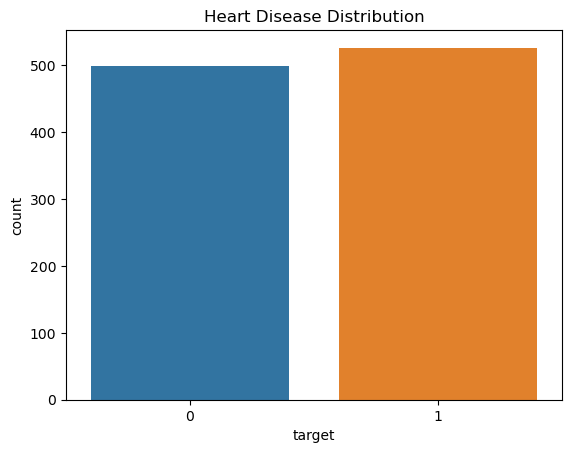

In [4]:
sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")

plt.show()

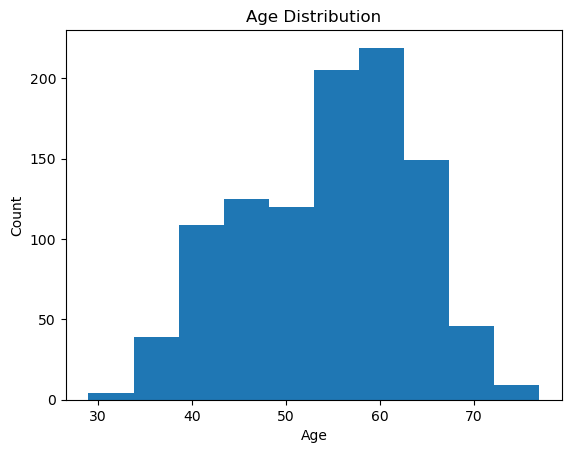

In [5]:
plt.hist(df['age'])

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

## Feature Selection

Features represent the medical attributes used to predict heart disease.

Target Variable:
target

In [6]:
X = df.drop('target', axis=1)

y = df['target']

## Train-Test Split
The dataset is divided into training and testing sets to evaluate model performance.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Logistic Regression

Logistic Regression is a commonly used classification algorithm suitable for binary classification problems.

In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7951219512195122


## Model 2: Decision Tree

Decision Tree classifiers work by splitting the dataset based on feature values to make predictions.

In [9]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366


## Model 3: Random Forest

Random Forest is an ensemble method that combines multiple decision trees to improve prediction accuracy.

In [10]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


## Model Comparison

The accuracy scores of all three models are compared to determine the best performing model.

In [11]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy': [
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.795122
1        Decision Tree  0.985366
2        Random Forest  0.985366


## Confusion Matrix

The confusion matrix provides a detailed breakdown of the model’s predictions compared to actual values.

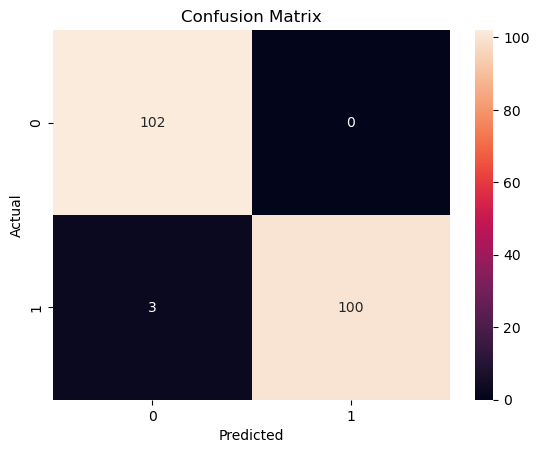

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Feature Importance

Feature importance helps identify which medical attributes contribute most to predicting heart disease.

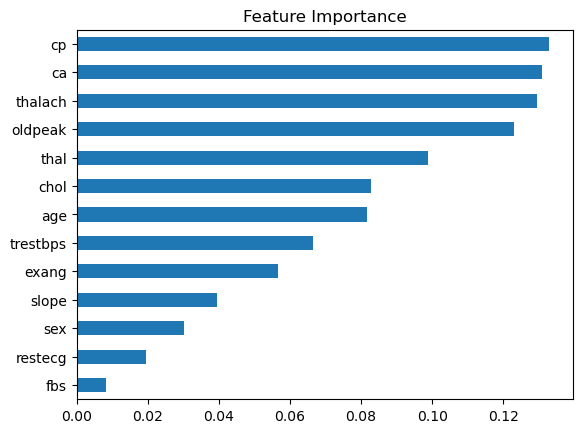

In [13]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")

plt.show()

## Conclusion

Three classification models were trained and evaluated to predict heart disease.

Among them, Random Forest achieved the highest accuracy and was selected as the best performing model.

The analysis shows that several medical factors such as chest pain type, cholesterol levels, and maximum heart rate play important roles in predicting heart disease.

Machine learning models like these can assist healthcare professionals in early detection and risk assessment of heart disease.